### Part 1: Neural Network Fundamentals and Training Behavior Analysis

In [72]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import os

In [73]:
os.makedirs('results', exist_ok=True)

### Task 1: Dataset Understanding

In [18]:
df = pd.read_csv("customer_churn_nn.csv")

In [19]:
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [20]:
df.shape

(2000, 17)

In [22]:
df.dtypes

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

In [21]:
df.isnull().sum()

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

In [23]:
df.describe

<bound method NDFrame.describe of      customer_id   region   plan_type   contract_type payment_method  \
0       CUST0001    South    Standard  Month-to-month     Debit Card   
1       CUST0002     West     Premium  Month-to-month         Wallet   
2       CUST0003  Central    Standard  Month-to-month    Credit Card   
3       CUST0004     West     Premium  Month-to-month    Credit Card   
4       CUST0005    North     Premium  Month-to-month    Net Banking   
...          ...      ...         ...             ...            ...   
1995    CUST1996     West    Standard  Month-to-month    Credit Card   
1996    CUST1997     East       Basic        One-year    Net Banking   
1997    CUST1998     West     Premium  Month-to-month    Net Banking   
1998    CUST1999    South  Enterprise  Month-to-month     Debit Card   
1999    CUST2000     West     Premium  Month-to-month    Net Banking   

      tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0                30            

In [49]:
df["churn"].value_counts()

churn
0    1969
1      31
Name: count, dtype: int64

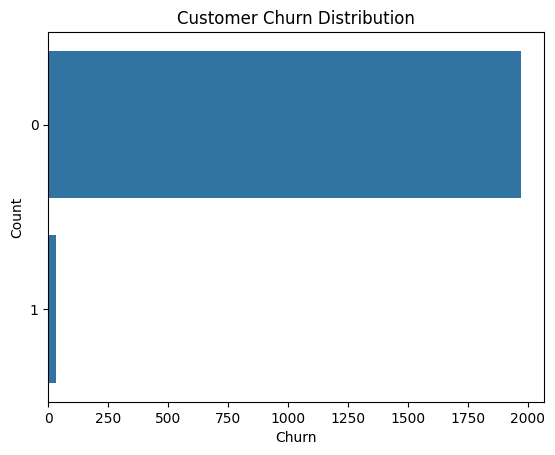

In [74]:
sns.countplot(y=df['churn'])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.savefig('results/task1_dataset_targetval.png', bbox_inches='tight', dpi=130)
plt.show()

### Task2: Data PreProcessing

In [46]:
df.drop("customer_id", axis=1, inplace=True)

X = df.drop("churn", axis=1)
y = df["churn"]


In [47]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count'],
      dtype='str')

Categorical Columns:
Index(['region', 'plan_type', 'contract_type', 'payment_method'], dtype='str')


In [51]:
num_imputer = SimpleImputer(strategy='mean')

X[num_cols] = num_imputer.fit_transform(X[num_cols])

In [52]:
cat_imputer = SimpleImputer(strategy='most_frequent')

X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [53]:
X = pd.get_dummies(X, drop_first=True)

In [54]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Training Shape: (1600, 24)
Testing Shape: (400, 24)


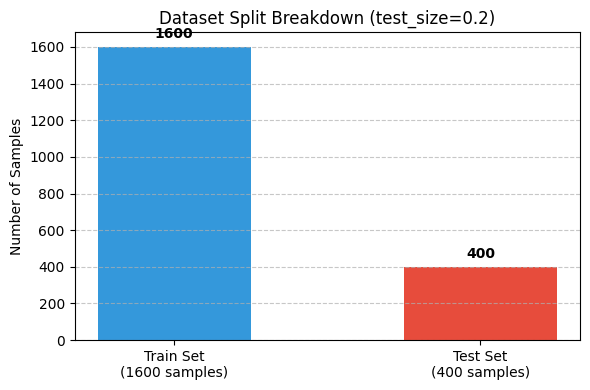

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]
labels = [f"Train Set\n({train_samples} samples)", f"Test Set\n({test_samples} samples)"]
sizes = [train_samples, test_samples]
colors = ["#3498db", "#e74c3c"]
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, sizes, color=colors, width=0.5)
plt.ylabel("Number of Samples")
plt.title("Dataset Split Breakdown (test_size=0.2)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (max(sizes) * 0.02),
        f"{yval}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
plt.tight_layout()
plt.savefig('results/task2_data_PreProcessing.png', bbox_inches='tight', dpi=130)
plt.show()


### Task 3: Neural Network Model Building

In [56]:
model = Sequential()

# Input + Hidden Layer
model.add(Dense(
    32,
    input_dim=X_train.shape[1],
    activation='relu'
))

# Hidden Layer
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

c:\Users\balaj\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 9.4712e-04
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 9.2436e-04
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 8.7561e-04
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 9.6948e-04 - val_accuracy: 1.0000 - val_loss: 8.4885e-04
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 9.3347e-04 - val_accuracy: 1.0000 - val_loss: 8.1850e-04
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.3168e-04 - val_accuracy: 1.0000 - val_loss: 8.0402e-04
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.203

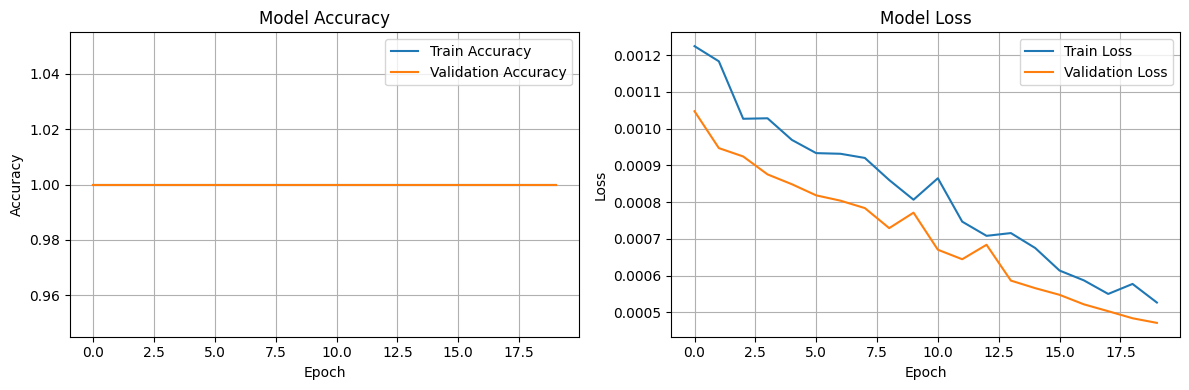

In [81]:
history = model.fit(
    X_train, y_train, 
    validation_data=(X_train, y_train), 
    epochs=20, 
    batch_size=32
)
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("results/Neural_Network_Modelling.png")
plt.show()

In [58]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

### Task 4: Training and Evaluation

In [59]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6461 - loss: 0.6478 - val_accuracy: 0.9531 - val_loss: 0.3852
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9836 - loss: 0.2736 - val_accuracy: 0.9781 - val_loss: 0.2048
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.1462 - val_accuracy: 0.9781 - val_loss: 0.1370
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0988 - val_accuracy: 0.9781 - val_loss: 0.1141
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0815 - val_accuracy: 0.9781 - val_loss: 0.1070
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0732 - val_accuracy: 0.9781 - val_loss: 0.1034
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0684 - val_accuracy: 0.9781 - val_loss: 0.1026
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0647 - val_accuracy: 0.9781 - val_loss

In [60]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

print("Training Loss:", train_loss)
print("Testing Loss:", test_loss)

Training Accuracy: 0.9937499761581421
Testing Accuracy: 0.987500011920929
Training Loss: 0.04607418179512024
Testing Loss: 0.10342403501272202


In [61]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


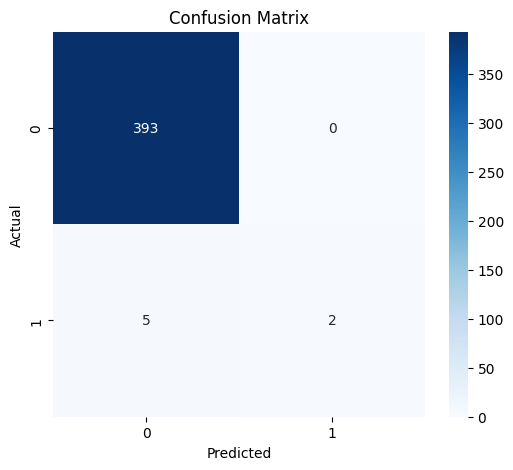

In [83]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('results/task4_COnfusion_Matrix.png', bbox_inches='tight', dpi=130)
plt.show()

In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       393
           1       1.00      0.29      0.44         7

    accuracy                           0.99       400
   macro avg       0.99      0.64      0.72       400
weighted avg       0.99      0.99      0.98       400



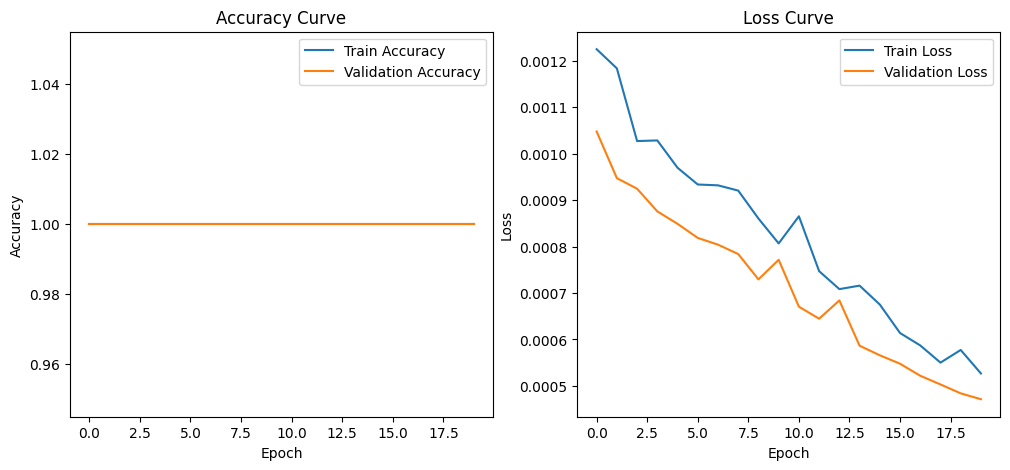

In [84]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

# Loss Plot
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.savefig('results/task4_Accuracy_or_Loss.png', bbox_inches='tight', dpi=130)
plt.show()

### Task 5: Hyperparameter Experimentation

In [65]:
def build_model(neurons=32,
                learning_rate=0.001,
                activation='relu'):

    model = Sequential()

    model.add(Dense(
        neurons,
        input_dim=X_train.shape[1],
        activation=activation
    ))

    model.add(Dense(
        neurons // 2,
        activation=activation
    ))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [66]:
experiments = [

    {
        "neurons": 16,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 50,
        "activation": "relu"
    },

    {
        "neurons": 32,
        "learning_rate": 0.001,
        "batch_size": 16,
        "epochs": 75,
        "activation": "relu"
    },

    {
        "neurons": 64,
        "learning_rate": 0.0005,
        "batch_size": 32,
        "epochs": 100,
        "activation": "tanh"
    }
]

In [67]:
results = []

for i, config in enumerate(experiments):

    print(f"\nRunning Experiment {i+1}")

    model = build_model(
        neurons=config['neurons'],
        learning_rate=config['learning_rate'],
        activation=config['activation']
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    results.append({
        "Experiment": i+1,
        "Neurons": config['neurons'],
        "Learning Rate": config['learning_rate'],
        "Batch Size": config['batch_size'],
        "Epochs": config['epochs'],
        "Activation": config['activation'],
        "Test Accuracy": accuracy,
        "Test Loss": loss
    })


Running Experiment 1


c:\Users\balaj\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Running Experiment 2

Running Experiment 3


   Experiment  Neurons  Learning Rate  Batch Size  Epochs Activation  \
0           1       16         0.0010          32      50       relu   
1           2       32         0.0010          16      75       relu   
2           3       64         0.0005          32     100       tanh   

   Test Accuracy  Test Loss  
0         0.9825   0.092554  
1         0.9800   0.267954  
2         0.9850   0.112082  


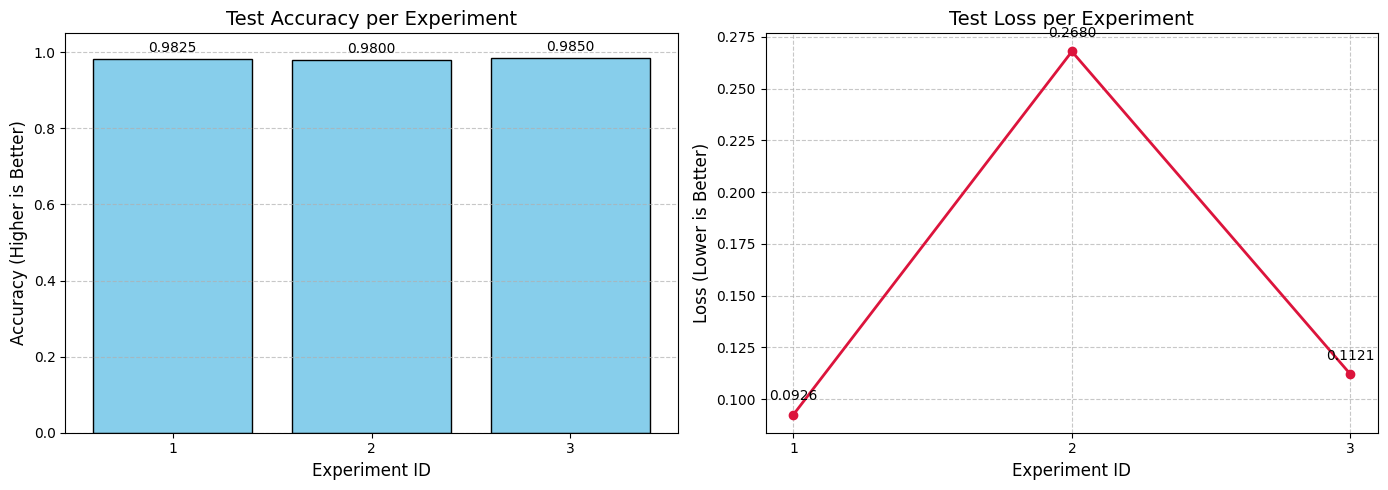

In [92]:
results_df = pd.DataFrame(results)

print(results_df)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(results_df["Experiment"].astype(str), results_df["Test Accuracy"], color="skyblue", edgecolor="black")
ax1.set_title("Test Accuracy per Experiment", fontsize=14)
ax1.set_xlabel("Experiment ID", fontsize=12)
ax1.set_ylabel("Accuracy (Higher is Better)", fontsize=12)
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for index, value in enumerate(results_df["Test Accuracy"]):
    ax1.text(index, value + 0.01, f"{value:.4f}", ha="center", va="bottom", fontsize=10)
ax2.plot(results_df["Experiment"].astype(str), results_df["Test Loss"], marker="o", color="crimson", linewidth=2)
ax2.set_title("Test Loss per Experiment", fontsize=14)
ax2.set_xlabel("Experiment ID", fontsize=12)
ax2.set_ylabel("Loss (Lower is Better)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

for index, value in enumerate(results_df["Test Loss"]):
    ax2.text(index, value + (max(results_df["Test Loss"]) * 0.02), f"{value:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("results/Model_comparison_Accuracy.PNG")
plt.show()



In [ ]:
results_df.to_csv(
    "results/model_comparison_table.csv",
    index=False
)


### Task 6: Final Reflection

1. Role of Weights and Biases

Weights determine how strongly each input feature influences predictions. During training, the neural network continuously updates these weights to reduce prediction errors.

Biases allow the activation function to shift left or right, improving model flexibility and learning capability.

2. Why Activation Function is Required

Activation functions introduce non-linearity into the model.

Without activation functions, a neural network behaves like a linear regression model and cannot learn complex relationships.

Common activation functions:

ReLU
Sigmoid
Tanh

3. Learning Rate Effects
High Learning Rate
Training becomes unstable
Loss fluctuates heavily
Model may overshoot optimal solution
Low Learning Rate
Training becomes very slow
Model may take too long to converge
4. Underfitting vs Overfitting
Underfitting

Occurs when:

Model is too simple
Both training and testing accuracy are low
Overfitting

Occurs when:

Training accuracy is very high
Testing accuracy is significantly lower

Overfitting can be identified when validation loss increases while training loss decreases.